# 02 · Data Pipeline & Graph Construction
## Delhivery ETA Optimisation · GraphSAGE Network Intelligence

**Objective:** Transform the cleaned trip-log (`trips_clean.parquet`) into a
production-ready, feature-rich directed graph that the GraphSAGE model will
train on. Every design decision here directly shapes the embedding quality.

| Phase | Notebook |
|-------|----------|
| 1 — EDA | `01_traditional_eda.ipynb` ✅ |
| **2 — Graph Construction (this notebook)** | Feature engineering → edge weights → NetworkX graph |
| 3 — GraphSAGE Training | Learn hub embeddings; train ETA regressor |

**Pipeline at a glance:**
```
trips_clean.parquet
       │
       ▼
[CELL 2] Load & validate
       │
       ▼
[CELL 3] Feature engineering  ← Time-of-Day buckets + derived columns
       │
       ▼
[CELL 4] Edge weight computation  ← Median(actual/osrm) per (src, dst, route_type, TOD)
       │
       ▼
[CELL 5] Node feature table  ← Per-hub congestion, dwell time, capacity proxy
       │
       ▼
[CELL 6] DiGraph vs MultiDiGraph decision (justified)
       │
       ▼
[CELL 7] NetworkX graph construction  ← Nodes + stratified edge attributes
       │
       ▼
[CELL 8] Graph analytics & validation
       │
       ▼
[CELL 9] Serialise artefacts  → graph.gpickle + node_features.parquet + edge_weights.parquet
```


---
## 1 · Imports & Configuration

In [1]:
# ============================================================
# CELL 1 — IMPORTS & GLOBAL CONFIGURATION
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import os
import json
import pickle
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

# ── Plotting aesthetics ──────────────────────────────────────
sns.set_theme(style="darkgrid", palette="muted", font_scale=1.15)
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "#F8F9FA",
    "axes.titleweight": "bold",
})
ACCENT = "#E74C3C"
OK     = "#2ECC71"
PURPLE = "#8E44AD"

# ── Reproducibility ─────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ── Path configuration ───────────────────────────────────────
DATA_DIR   = Path("../data")
OUTPUT_DIR = Path("../data")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLEAN_PARQUET = DATA_DIR / "trips_clean.parquet"

# ── Time-of-Day schema (single source of truth) ──────────────
# Used in both feature engineering AND edge stratification.
# Bins are LEFT-INCLUSIVE, RIGHT-EXCLUSIVE: [0,6) = Night 0–6 etc.
TOD_BINS   = [0, 6, 10, 16, 20, 24]
TOD_LABELS = [
    "Night_0_6",       # 00:00–05:59 — overnight hauls, minimal traffic
    "Morning_6_10",    # 06:00–09:59 — morning rush, urban congestion peak
    "Afternoon_10_16", # 10:00–15:59 — midday, intercity movement
    "Evening_16_20",   # 16:00–19:59 — evening rush, return traffic
    "Night_20_24",     # 20:00–23:59 — post-rush, moderate flow
]

# ── Outlier thresholds (must match 01_traditional_eda.ipynb) ─
LOWER_FACTOR = 0.2
UPPER_FACTOR = 10.0
MIN_DIST_KM  = 0.1
MIN_TIME_MIN = 1.0

print("✅  Imports OK")
print(f"   networkx {nx.__version__} | pandas {pd.__version__} | numpy {np.__version__}")
print(f"   Time-of-Day buckets: {TOD_LABELS}")


✅  Imports OK
   networkx 3.6.1 | pandas 3.0.3 | numpy 2.4.6
   Time-of-Day buckets: ['Night_0_6', 'Morning_6_10', 'Afternoon_10_16', 'Evening_16_20', 'Night_20_24']


---
## 2 · Load & Validate Cleaned Data

We consume the `trips_clean.parquet` produced by `01_traditional_eda.ipynb`.
If it doesn't exist yet (e.g. first run), we fall back to loading raw shards
and re-applying the same cleaning logic inline.


In [2]:
# ============================================================
# CELL 2 — LOAD & VALIDATE CLEANED DATA
# ============================================================

import glob

def _apply_cleaning(df: pd.DataFrame) -> pd.DataFrame:
    """
    Mirror the outlier filters from 01_traditional_eda.ipynb.
    Called only when the pre-cleaned parquet is unavailable.
    """
    df = df.dropna(subset=["source_center", "destination_center",
                            "actual_time",   "osrm_time"])
    mask = (
        (df["actual_time"]                    >= MIN_TIME_MIN) &
        (df["osrm_time"]                      >= MIN_TIME_MIN) &
        (df["factor"]                         >= LOWER_FACTOR) &
        (df["factor"]                         <= UPPER_FACTOR) &
        (df["segment_factor"]                 >= 0           ) &
        (df["actual_distance_to_destination"] >= MIN_DIST_KM )
    )
    return df[mask].copy()


def load_data(clean_path: Path, raw_dir: Path) -> pd.DataFrame:
    """
    Load trip data from the pre-cleaned parquet if available,
    otherwise load raw shards and clean inline.

    Parameters
    ----------
    clean_path : Path
        Expected location of trips_clean.parquet.
    raw_dir : Path
        Directory containing data_part_*.csv shards.

    Returns
    -------
    pd.DataFrame
        Validated, cleaned trip-segment DataFrame.
    """
    if clean_path.exists():
        print(f"📂 Loading pre-cleaned data from: {clean_path}")
        df = pd.read_parquet(clean_path)
        # Re-parse timestamps if they were serialised as strings
        for col in ["trip_creation_time", "od_start_time", "od_end_time"]:
            if col in df.columns and df[col].dtype == object:
                df[col] = pd.to_datetime(df[col])
        print(f"   ✅ Loaded  {len(df):,} rows × {df.shape[1]} columns")
        return df

    # ── Fallback: raw shards ─────────────────────────────────
    print(f"⚠️  {clean_path} not found — loading raw shards from {raw_dir}")
    shards = sorted(glob.glob(str(raw_dir / "data_part_*.csv")))
    if not shards:
        raise FileNotFoundError(
            f"No raw shards found in {raw_dir}. "
            "Run 01_traditional_eda.ipynb first or place CSVs in ../data/"
        )
    DATE_COLS = ["trip_creation_time", "od_start_time", "od_end_time", "cutoff_timestamp"]
    parts = [pd.read_csv(s, parse_dates=DATE_COLS, low_memory=False) for s in shards]
    df = pd.concat(parts, ignore_index=True)
    print(f"   Loaded {len(df):,} raw rows from {len(shards)} shard(s)")
    df = _apply_cleaning(df)
    print(f"   After cleaning: {len(df):,} rows")
    return df


df = load_data(CLEAN_PARQUET, DATA_DIR)

# ── Schema validation ────────────────────────────────────────
REQUIRED_COLS = [
    "trip_creation_time", "source_center", "destination_center",
    "route_type", "actual_time", "osrm_time", "factor",
    "segment_actual_time", "segment_osrm_time", "segment_factor",
    "actual_distance_to_destination", "is_cutoff",
    "start_scan_to_end_scan", "trip_uuid",
]
missing = [c for c in REQUIRED_COLS if c not in df.columns]
assert not missing, f"Missing required columns: {missing}"

# ── Ensure datetime types ────────────────────────────────────
df["trip_creation_time"] = pd.to_datetime(df["trip_creation_time"])

print(f"\n📊 Dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Train rows    : {(df['data']=='training').sum():,}")
print(f"   Test rows     : {(df['data']=='test').sum():,}")
print(f"   Unique hubs   : {pd.concat([df['source_center'], df['destination_center']]).nunique():,}")
print(f"   Date range    : {df['trip_creation_time'].min().date()} → {df['trip_creation_time'].max().date()}")


📂 Loading pre-cleaned data from: ../data/trips_clean.parquet
   ✅ Loaded  141,865 rows × 28 columns

📊 Dataset shape : 141,865 rows × 28 columns
   Train rows    : 102,702
   Test rows     : 39,163
   Unique hubs   : 1,655
   Date range    : 2018-09-12 → 2018-10-03


---
## 3 · Feature Engineering

We derive every temporal and ratio feature needed for edge-weight computation
and node-feature construction. All new columns are annotated with their
downstream purpose.

| New column | Formula / Logic | Used in |
|---|---|---|
| `hour_of_day` | `trip_creation_time.dt.hour` | TOD binning |
| `day_of_week` | `trip_creation_time.dt.dayofweek` | Node features |
| `is_weekend` | `day_of_week ∈ {5,6}` | Edge stratification (optional) |
| `time_of_day` | `pd.cut(hour, bins, labels)` | **Primary edge stratification key** |
| `delay_ratio` | `actual_time / osrm_time` | **Primary edge weight** |
| `segment_delay_ratio` | `segment_actual_time / segment_osrm_time` | Segment-level graph refinement |
| `speed_kmph` | `osrm_distance / (osrm_time / 60)` | Outlier verification |


✅ delay_ratio == factor  (max abs diff = 0.00e+00)

=== Time-of-Day Distribution ===
  Night_0_6               41,232  ██████████████████████████████
  Morning_6_10            12,926  █████████
  Afternoon_10_16         20,564  ██████████████
  Evening_16_20           27,425  ███████████████████
  Night_20_24             39,718  ████████████████████████████

=== Delay Ratio Summary ===
count    141865.0000
mean          2.0339
std           0.8654
min           0.2031
5%            1.1818
25%           1.6011
50%           1.8526
75%           2.2000
95%           3.4713
99%           5.8819
max          10.0000


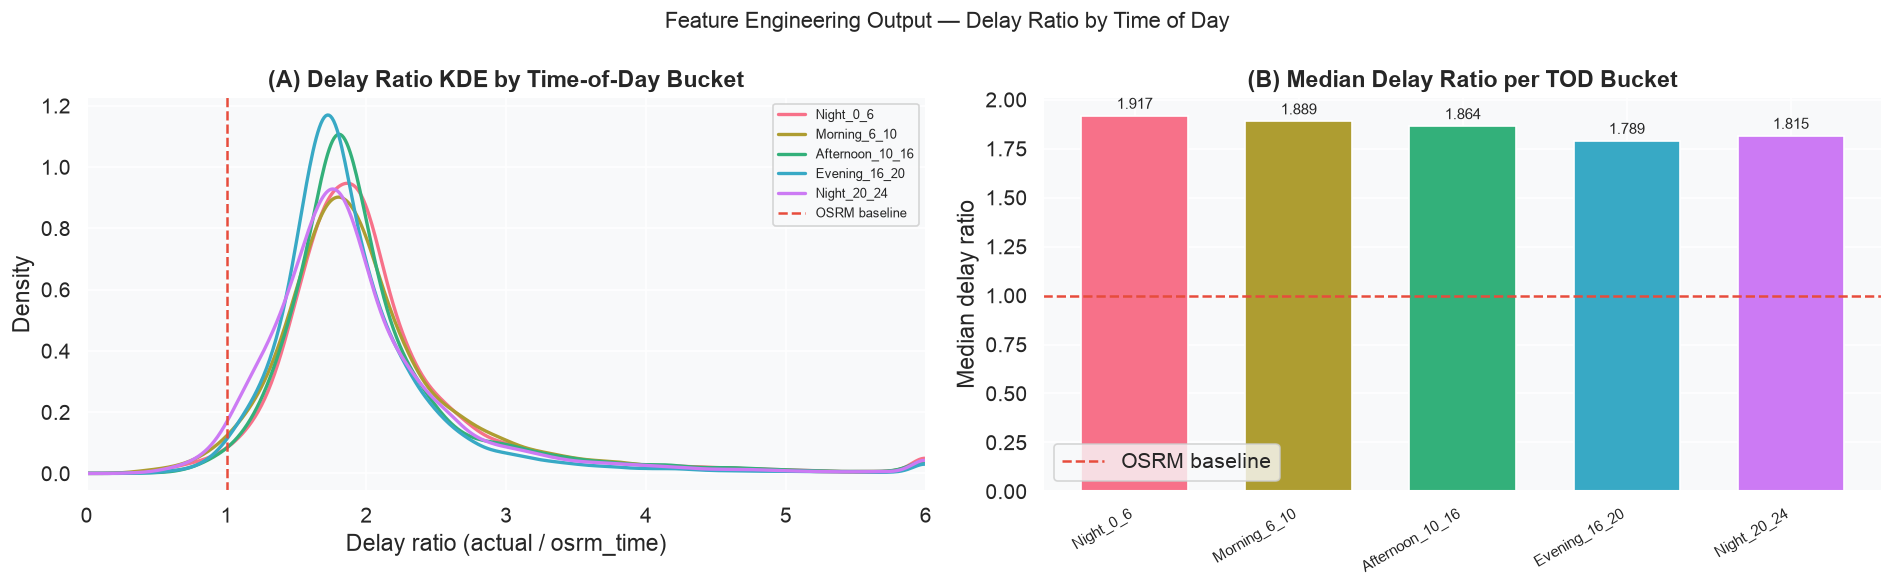


→ Plot saved: feature_delay_ratio_tod.png


In [3]:
# ============================================================
# CELL 3 — FEATURE ENGINEERING
# ============================================================

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Derive all temporal and delay-ratio features required for graph
    construction.

    Parameters
    ----------
    df : pd.DataFrame
        Cleaned trip-segment DataFrame from Cell 2.

    Returns
    -------
    pd.DataFrame
        Input DataFrame with new derived columns appended in-place.

    Notes
    -----
    `delay_ratio` is computed directly from raw columns rather than
    reusing the `factor` column to make the derivation explicit and
    auditable. Both should be numerically identical (verified below).

    The `time_of_day` bucketing uses RIGHT=False (left-inclusive intervals)
    so that midnight trips [0,6) are consistently labelled Night_0_6
    regardless of floating-point rounding in the hour.
    """
    df = df.copy()

    # ── Temporal features ────────────────────────────────────
    df["hour_of_day"] = df["trip_creation_time"].dt.hour.astype("int8")
    df["day_of_week"] = df["trip_creation_time"].dt.dayofweek.astype("int8")
    df["is_weekend"]  = df["day_of_week"].isin([5, 6])
    df["month"]       = df["trip_creation_time"].dt.month.astype("int8")

    # ── Time-of-Day bucket (primary stratification key) ──────
    # Rationale for these bins (operations domain knowledge):
    #   Night  0–6:  overnight linehaul — highways clear, fastest legs
    #   Morning 6–10: morning rush — urban last-mile heavily congested
    #   Afternoon 10–16: midday intercity — moderate, stable flow
    #   Evening 16–20: return rush — second congestion peak
    #   Night 20–24:  post-rush — improving but denser than 0–6
    df["time_of_day"] = pd.cut(
        df["hour_of_day"],
        bins=TOD_BINS,
        labels=TOD_LABELS,
        right=False,      # [0,6), [6,10), …  — left-inclusive
        include_lowest=True,
    )

    # ── Delay ratio — the core edge weight signal ─────────────
    # Formula:  W_raw = actual_time / osrm_time
    # This is numerically identical to the pre-computed `factor` column.
    # We recompute it here to keep this notebook self-contained and to
    # make the derivation transparent for code review.
    df["delay_ratio"] = df["actual_time"] / df["osrm_time"]

    # ── Segment-level delay ratio ────────────────────────────
    # Useful for multi-hop routes where segment-level accuracy matters.
    # Guard against zero OSRM segment times (should be rare post-cleaning).
    df["segment_delay_ratio"] = np.where(
        df["segment_osrm_time"] > 0,
        df["segment_actual_time"] / df["segment_osrm_time"],
        np.nan,
    )

    # ── Speed sanity column (for downstream QA) ──────────────
    df["speed_kmph"] = df["osrm_distance"] / (df["osrm_time"] / 60.0)

    # ── Normalised dwell time ────────────────────────────────
    # start_scan_to_end_scan is in minutes; we log-transform to reduce
    # skew before it's used as a node feature.
    df["log_dwell_time"] = np.log1p(df["start_scan_to_end_scan"].clip(lower=0))

    return df


df = engineer_features(df)

# ── Audit: delay_ratio must equal factor ────────────────────
ratio_match = (df["delay_ratio"] - df["factor"]).abs().max()
assert ratio_match < 1e-4, f"delay_ratio ≠ factor! max diff={ratio_match:.6f}"
print(f"✅ delay_ratio == factor  (max abs diff = {ratio_match:.2e})")

# ── Distribution of new features ────────────────────────────
print("\n=== Time-of-Day Distribution ===")
tod_counts = df["time_of_day"].value_counts().sort_index()
for lbl, cnt in tod_counts.items():
    bar = "█" * int(cnt / tod_counts.max() * 30)
    print(f"  {lbl:<22} {cnt:>7,}  {bar}")

print("\n=== Delay Ratio Summary ===")
print(df["delay_ratio"].describe(percentiles=[0.05,0.25,0.5,0.75,0.95,0.99]).round(4).to_string())

# ── Visual: delay ratio by TOD ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Feature Engineering Output — Delay Ratio by Time of Day", fontsize=13)

ax = axes[0]
colors = sns.color_palette("husl", len(TOD_LABELS))
for i, (lbl, grp) in enumerate(df.groupby("time_of_day", observed=True)):
    grp["delay_ratio"].clip(0, 6).plot.kde(ax=ax, color=colors[i],
                                            linewidth=2, label=lbl)
ax.axvline(1.0, color=ACCENT, linestyle="--", linewidth=1.5, label="OSRM baseline")
ax.set_xlabel("Delay ratio (actual / osrm_time)")
ax.set_title("(A) Delay Ratio KDE by Time-of-Day Bucket")
ax.legend(fontsize=8)
ax.set_xlim(0, 6)

ax = axes[1]
tod_order = TOD_LABELS
medians   = [df[df["time_of_day"]==t]["delay_ratio"].median() for t in tod_order]
bars = ax.bar(range(len(tod_order)), medians, color=colors, edgecolor="white", width=0.65)
ax.axhline(1.0, color=ACCENT, linestyle="--", linewidth=1.5, label="OSRM baseline")
ax.set_xticks(range(len(tod_order)))
ax.set_xticklabels(tod_order, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Median delay ratio")
ax.set_title("(B) Median Delay Ratio per TOD Bucket")
for bar, val in zip(bars, medians):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)
ax.legend()

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "feature_delay_ratio_tod.png"), bbox_inches="tight")
plt.show()
print("\n→ Plot saved: feature_delay_ratio_tod.png")


---
## 4 · Edge Weight Computation

### Why Median, not Mean?

The delay ratio distribution is **right-skewed** (confirmed in EDA: tail extends
to 10×). The arithmetic mean is pulled by extreme events (floods, breakdowns,
festivals) that are real but rare. The **median** is a robust estimator of the
*typical* corridor behaviour — which is what we want the graph edge to represent.
An upstream outlier event should influence the graph through its own trip records,
not by contaminating the median of an otherwise healthy corridor.

### Stratification Keys

Each graph edge is uniquely identified by:

```
(source_center, destination_center, route_type, time_of_day)
```

This means a single physical corridor (e.g. BLR → HYD) can have up to
**10 distinct edges** (2 route types × 5 TOD slots), each carrying its own
empirically-observed delay weight.


Training rows used for weight computation: 102,702

=== Stratified Edge Table ===
  Total edges (src, dst, route_type, TOD): 3,983
  FTL edges   : 2,280
  Carting edges: 1,703
  Low-support edges (< 5 trips): 1,159  (29.1%)

=== Edge Weight (Median Delay Ratio) Distribution ===
count    3983.0000
mean        2.1481
std         0.9968
min         0.3999
5%          1.1744
25%         1.5873
50%         1.9167
75%         2.3958
95%         3.8916
99%         6.3478
max         9.8769

=== Sample Rows ===
source_center destination_center route_type     time_of_day  edge_weight  mean_delay_ratio  std_delay_ratio  trip_count  median_actual_time  median_osrm_time  median_dist_km  cutoff_rate  p95_delay_ratio  low_support
 IND000000AAL       IND411033AAA    Carting       Night_0_6     2.123333          2.123333         0.061283           2                39.0              18.5       12.689285     0.500000         2.162333         True
 IND000000AAL       IND411033AAA    Carting    Morning_6_

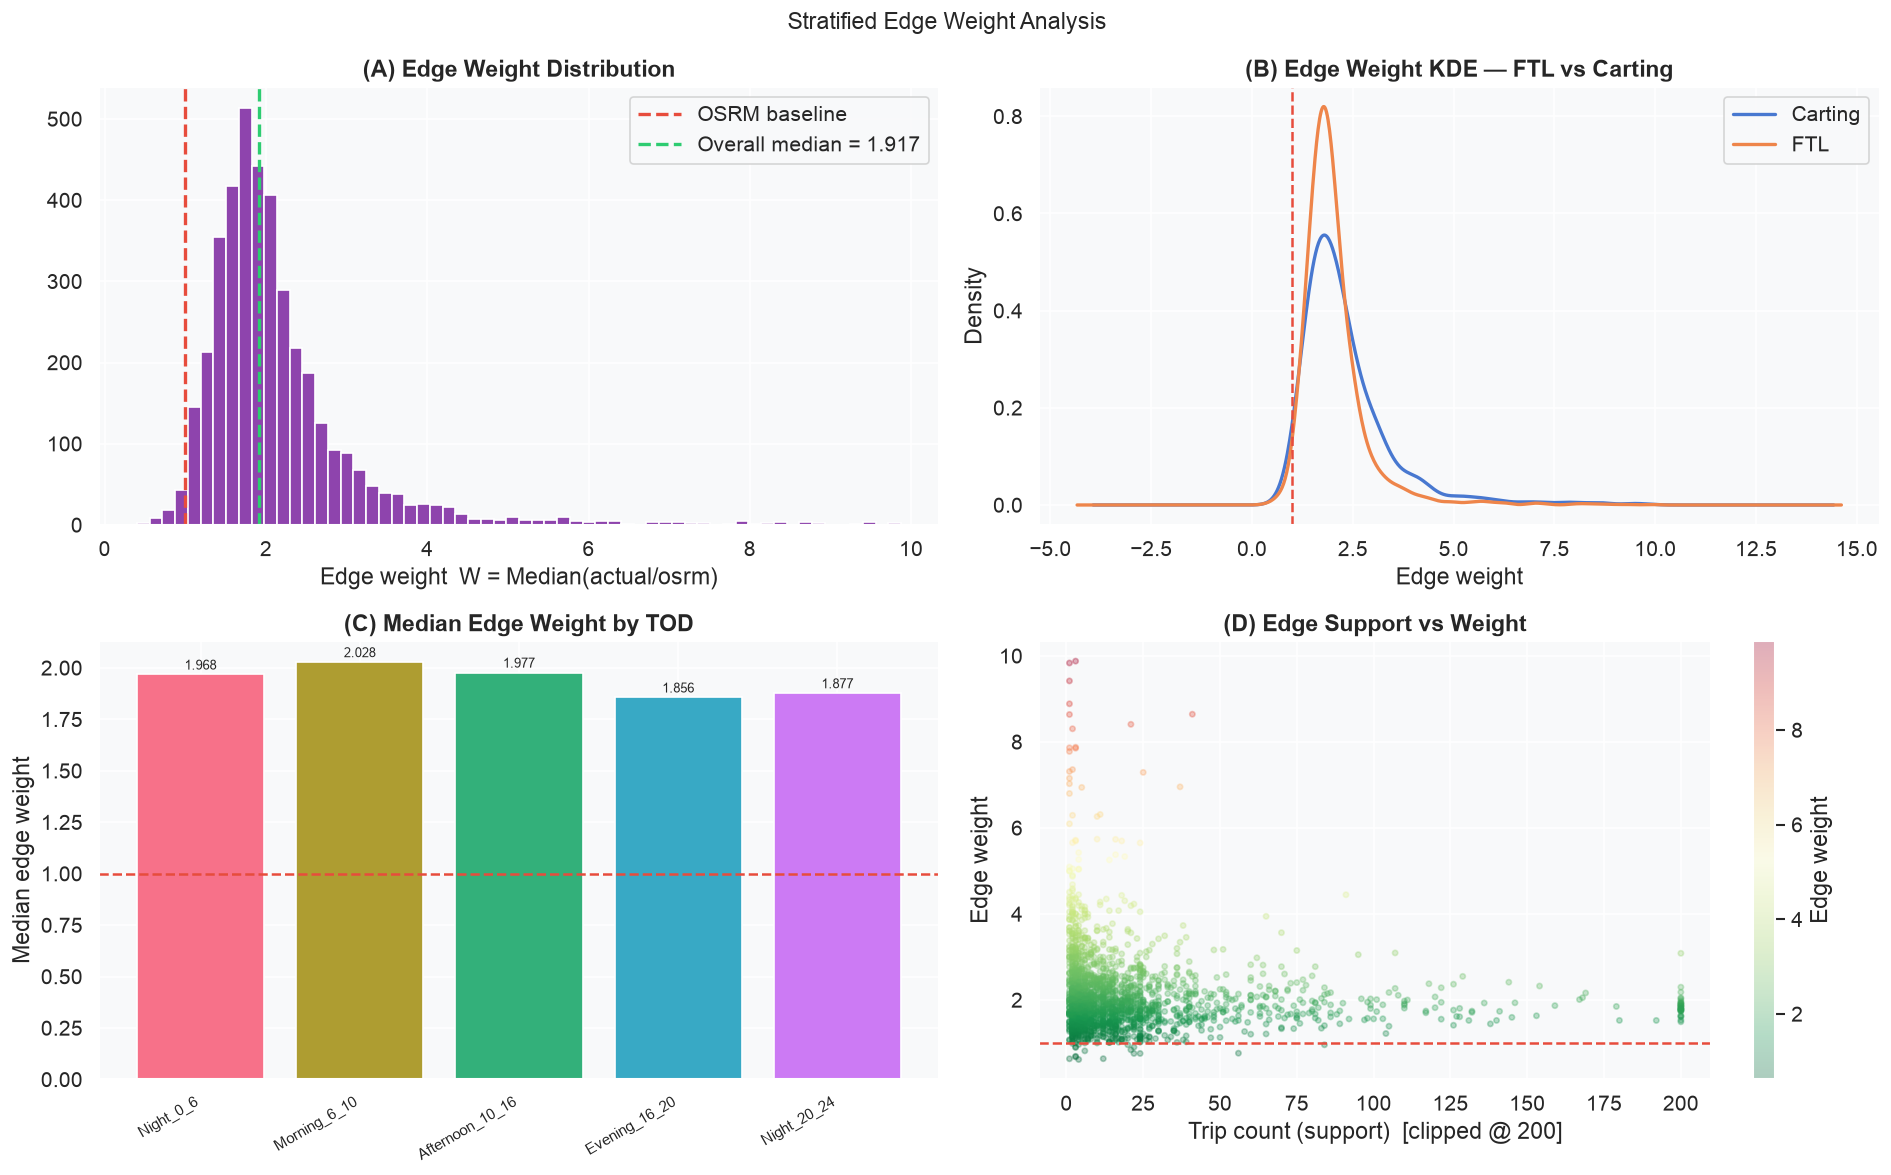


→ Plot saved: edge_weight_analysis.png


In [4]:
# ============================================================
# CELL 4 — STRATIFIED EDGE WEIGHT COMPUTATION
# ============================================================

# ── TRAINING-ONLY data for weight calibration ────────────────
# IMPORTANT: edge weights are computed exclusively from the training
# split to prevent data leakage into the test evaluation.
df_train = df[df["data"] == "training"].copy()
print(f"Training rows used for weight computation: {len(df_train):,}")

GROUPBY_KEYS = ["source_center", "destination_center", "route_type", "time_of_day"]


def compute_edge_weights(df_train: pd.DataFrame) -> pd.DataFrame:
    """
    Compute stratified edge weights as the **median delay ratio** for each
    (source, destination, route_type, time_of_day) corridor.

    The edge weight formula is:
        W = Median( actual_time / osrm_time )
          = Median( delay_ratio )

    Additional descriptive statistics are stored as auxiliary edge
    attributes for use as secondary GraphSAGE edge features.

    Parameters
    ----------
    df_train : pd.DataFrame
        Training-split trips with `delay_ratio` and `time_of_day` columns.

    Returns
    -------
    pd.DataFrame
        One row per stratified edge with columns:
        - source_center, destination_center, route_type, time_of_day
        - edge_weight         : Median(delay_ratio)  ← PRIMARY graph weight
        - mean_delay_ratio    : Mean (auxiliary feature)
        - std_delay_ratio     : Std  (uncertainty / volatility feature)
        - trip_count          : Support (low-count edges are less reliable)
        - median_actual_time  : Median actual travel time (minutes)
        - median_osrm_time    : Median OSRM estimate (minutes)
        - median_dist_km      : Median corridor distance (km)
        - cutoff_rate         : Fraction of trips that were cut off (hub congestion proxy)
        - p95_delay_ratio     : 95th-percentile ratio (worst-case planning)
    """
    edge_df = (
        df_train
        .groupby(GROUPBY_KEYS, observed=True)
        .agg(
            # ── PRIMARY WEIGHT ───────────────────────────────
            edge_weight        = ("delay_ratio",                   "median"),
            # ── AUXILIARY EDGE FEATURES ──────────────────────
            mean_delay_ratio   = ("delay_ratio",                   "mean"),
            std_delay_ratio    = ("delay_ratio",                   "std"),
            trip_count         = ("trip_uuid",                     "count"),
            median_actual_time = ("actual_time",                   "median"),
            median_osrm_time   = ("osrm_time",                     "median"),
            median_dist_km     = ("actual_distance_to_destination", "median"),
            cutoff_rate        = ("is_cutoff",                     "mean"),
            p95_delay_ratio    = ("delay_ratio",                   lambda x: x.quantile(0.95)),
        )
        .reset_index()
        .dropna(subset=["edge_weight"])   # drop strata with no valid ratio
    )

    # ── Reliability flag: edges with < 5 trips get low_support=True ──
    # Low-support edges carry less statistical confidence; downstream
    # GraphSAGE training can down-weight or mask them.
    edge_df["low_support"] = edge_df["trip_count"] < 5

    return edge_df


edge_weights_df = compute_edge_weights(df_train)

# ── Summary statistics ───────────────────────────────────────
print(f"\n=== Stratified Edge Table ===")
print(f"  Total edges (src, dst, route_type, TOD): {len(edge_weights_df):,}")
print(f"  FTL edges   : {(edge_weights_df.route_type=='FTL').sum():,}")
print(f"  Carting edges: {(edge_weights_df.route_type=='Carting').sum():,}")
print(f"  Low-support edges (< 5 trips): {edge_weights_df['low_support'].sum():,}  "
      f"({edge_weights_df['low_support'].mean()*100:.1f}%)")

print("\n=== Edge Weight (Median Delay Ratio) Distribution ===")
print(edge_weights_df["edge_weight"].describe(
    percentiles=[0.05,0.25,0.5,0.75,0.95,0.99]).round(4).to_string())

print("\n=== Sample Rows ===")
print(edge_weights_df.head(8).to_string(index=False))

# ── Visualise edge weights ───────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Stratified Edge Weight Analysis", fontsize=14)

# (A) Edge weight distribution overall
ax = axes[0, 0]
edge_weights_df["edge_weight"].hist(bins=60, ax=ax, color=PURPLE, edgecolor="white")
ax.axvline(1.0, color=ACCENT, linestyle="--", linewidth=2, label="OSRM baseline")
ax.axvline(edge_weights_df["edge_weight"].median(), color=OK, linestyle="--",
           linewidth=2, label=f"Overall median = {edge_weights_df['edge_weight'].median():.3f}")
ax.set_xlabel("Edge weight  W = Median(actual/osrm)")
ax.set_title("(A) Edge Weight Distribution")
ax.legend()

# (B) Edge weight by route_type
ax = axes[0, 1]
for rt, grp in edge_weights_df.groupby("route_type"):
    grp["edge_weight"].plot.kde(ax=ax, linewidth=2, label=rt)
ax.axvline(1.0, color=ACCENT, linestyle="--", linewidth=1.5)
ax.set_xlabel("Edge weight")
ax.set_title("(B) Edge Weight KDE — FTL vs Carting")
ax.legend()

# (C) Median edge weight by TOD
ax = axes[1, 0]
tod_ew = edge_weights_df.groupby("time_of_day", observed=True)["edge_weight"].median()
colors = sns.color_palette("husl", len(TOD_LABELS))
bars = ax.bar(range(len(TOD_LABELS)),
              [tod_ew.get(t, np.nan) for t in TOD_LABELS],
              color=colors, edgecolor="white")
ax.set_xticks(range(len(TOD_LABELS)))
ax.set_xticklabels(TOD_LABELS, rotation=30, ha="right", fontsize=9)
ax.axhline(1.0, color=ACCENT, linestyle="--", linewidth=1.5)
ax.set_ylabel("Median edge weight")
ax.set_title("(C) Median Edge Weight by TOD")
for bar, val in zip(bars, [tod_ew.get(t, 0) for t in TOD_LABELS]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=8)

# (D) Trip count vs edge weight (support vs weight scatter)
ax = axes[1, 1]
sample = edge_weights_df.sample(min(2000, len(edge_weights_df)), random_state=RANDOM_SEED)
sc = ax.scatter(sample["trip_count"].clip(upper=200), sample["edge_weight"],
                alpha=0.3, s=10, c=sample["edge_weight"], cmap="RdYlGn_r")
ax.axhline(1.0, color=ACCENT, linestyle="--", linewidth=1.5)
ax.set_xlabel("Trip count (support)  [clipped @ 200]")
ax.set_ylabel("Edge weight")
ax.set_title("(D) Edge Support vs Weight")
plt.colorbar(sc, ax=ax, label="Edge weight")

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "edge_weight_analysis.png"), bbox_inches="tight")
plt.show()
print("\n→ Plot saved: edge_weight_analysis.png")


---
## 5 · Node Feature Construction

GraphSAGE aggregates **neighbourhood information** into node embeddings.
The quality of those embeddings depends on the richness of the initial node
feature vector. We construct one feature row per logistics hub from the
training data.

| Feature | Description | GraphSAGE role |
|---|---|---|
| `avg_congestion_factor` | Median delay ratio across all outbound trips | Hub's baseline "heaviness" |
| `cutoff_rate` | Fraction of departures that were cut off | Hub processing overload proxy |
| `avg_dwell_time_min` | Median scan-to-scan dwell at this hub | Processing capacity signal |
| `log_dwell_time` | Log-scaled dwell (reduces skew) | Normalised input feature |
| `unique_destinations` | Out-degree (# distinct downstream hubs) | Hub centrality |
| `unique_sources` | In-degree (# distinct upstream hubs) | Hub connectivity |
| `outbound_trips` | Total outbound volume | Traffic load |
| `ftl_ratio` | Fraction of outbound trips that are FTL | Route-type mix |
| `p75_delay_ratio` | 75th-percentile delay ratio | Congestion tail risk |
| `weekend_congestion_delta` | Weekend median factor − Weekday median | Temporal volatility |


=== Node Feature Table ===
  Total nodes : 1,588
  Features    : ['outbound_trips', 'avg_congestion_factor', 'p75_delay_ratio', 'std_delay_ratio', 'cutoff_rate', 'avg_dwell_time_min', 'log_dwell_time', 'unique_destinations', 'ftl_count', 'ftl_ratio', 'weekend_congestion_delta', 'inbound_trips', 'unique_sources']

Sample (top 5 hubs by outbound volume):
              outbound_trips  avg_congestion_factor  p75_delay_ratio  std_delay_ratio  cutoff_rate  avg_dwell_time_min  log_dwell_time  unique_destinations  ftl_count  ftl_ratio  weekend_congestion_delta  inbound_trips  unique_sources
hub_id                                                                                                                                                                                                                                    
IND000000ACB         16431.0                 1.8240           2.0212           0.5219       0.9547              2204.0          7.6985                 48.0    13965.0     0.84

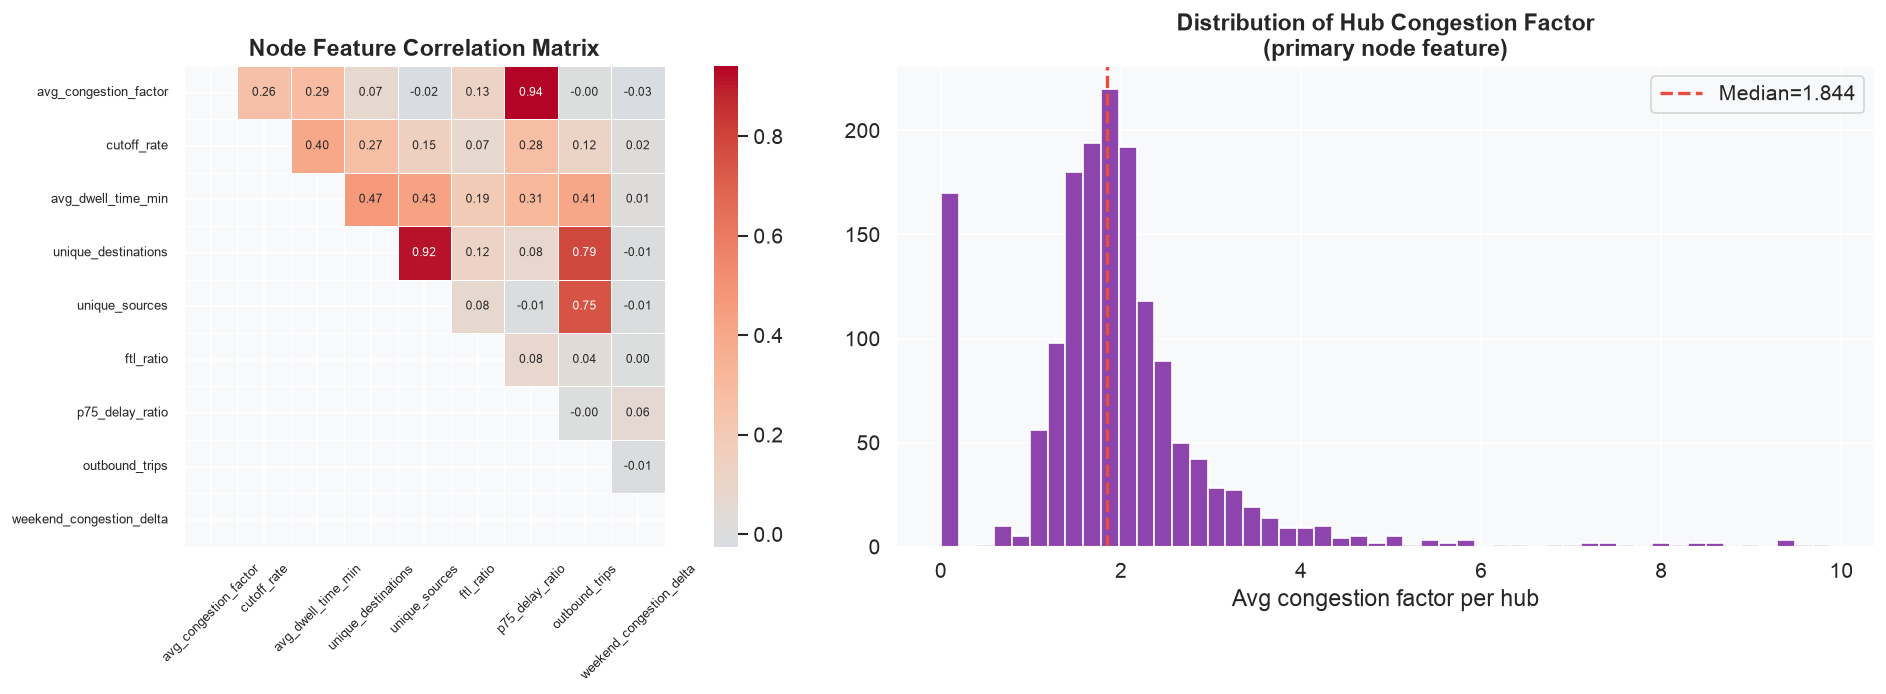


→ Plot saved: node_feature_analysis.png


In [5]:
# ============================================================
# CELL 5 — NODE FEATURE CONSTRUCTION
# ============================================================

def build_node_features(df_train: pd.DataFrame) -> pd.DataFrame:
    """
    Construct a feature vector for each logistics hub (node) in the graph.

    We compute features from the perspective of each hub as a **source**
    (outbound behaviour) and separately as a **destination** (inbound
    behaviour), then merge them into a single row per hub.

    Parameters
    ----------
    df_train : pd.DataFrame
        Training-split DataFrame with engineered features from Cell 3.

    Returns
    -------
    pd.DataFrame
        One row per hub with numeric feature columns and a `hub_id` index.
    """

    # ── OUTBOUND features (hub as source) ────────────────────
    outbound = (
        df_train
        .groupby("source_center", observed=True)
        .agg(
            outbound_trips         = ("trip_uuid",        "count"),
            avg_congestion_factor  = ("delay_ratio",      "median"),
            p75_delay_ratio        = ("delay_ratio",      lambda x: x.quantile(0.75)),
            std_delay_ratio        = ("delay_ratio",      "std"),
            cutoff_rate            = ("is_cutoff",        "mean"),
            avg_dwell_time_min     = ("start_scan_to_end_scan", "median"),
            log_dwell_time         = ("log_dwell_time",   "median"),
            unique_destinations    = ("destination_center", "nunique"),
        )
        .reset_index()
        .rename(columns={"source_center": "hub_id"})
    )

    # ── FTL ratio per hub ────────────────────────────────────
    ftl_counts = (
        df_train[df_train["route_type"] == "FTL"]
        .groupby("source_center", observed=True)
        .size()
        .reset_index(name="ftl_count")
        .rename(columns={"source_center": "hub_id"})
    )
    outbound = outbound.merge(ftl_counts, on="hub_id", how="left")
    outbound["ftl_count"]  = outbound["ftl_count"].fillna(0)
    outbound["ftl_ratio"]  = outbound["ftl_count"] / outbound["outbound_trips"]

    # ── Weekend vs weekday congestion delta ──────────────────
    wknd = (
        df_train
        .groupby(["source_center", "is_weekend"], observed=True)["delay_ratio"]
        .median()
        .unstack("is_weekend")
        .rename(columns={False: "weekday_factor", True: "weekend_factor"})
        .reset_index()
        .rename(columns={"source_center": "hub_id"})
    )
    wknd["weekend_congestion_delta"] = (
        wknd.get("weekend_factor", 0) - wknd.get("weekday_factor", 0)
    )
    outbound = outbound.merge(
        wknd[["hub_id", "weekend_congestion_delta"]],
        on="hub_id", how="left"
    )

    # ── INBOUND features (hub as destination) ────────────────
    inbound = (
        df_train
        .groupby("destination_center", observed=True)
        .agg(
            inbound_trips   = ("trip_uuid",      "count"),
            unique_sources  = ("source_center",  "nunique"),
        )
        .reset_index()
        .rename(columns={"destination_center": "hub_id"})
    )

    # ── Merge outbound + inbound ─────────────────────────────
    # Use outer join: some hubs appear only as source or only as destination
    node_df = outbound.merge(inbound, on="hub_id", how="outer")

    # Fill missing inbound/outbound stats with 0
    fill_cols = [
        "outbound_trips", "inbound_trips", "avg_congestion_factor",
        "cutoff_rate", "unique_destinations", "unique_sources", "ftl_ratio",
        "p75_delay_ratio", "std_delay_ratio", "weekend_congestion_delta",
        "avg_dwell_time_min", "log_dwell_time",
    ]
    node_df[fill_cols] = node_df[fill_cols].fillna(0)

    return node_df.set_index("hub_id")


node_features_df = build_node_features(df_train)

print(f"=== Node Feature Table ===")
print(f"  Total nodes : {len(node_features_df):,}")
print(f"  Features    : {list(node_features_df.columns)}")
print(f"\nSample (top 5 hubs by outbound volume):")
print(
    node_features_df
    .sort_values("outbound_trips", ascending=False)
    .head(5)
    .round(4)
    .to_string()
)

# ── Correlation heatmap of node features ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax = axes[0]
feat_cols = [
    "avg_congestion_factor", "cutoff_rate", "avg_dwell_time_min",
    "unique_destinations", "unique_sources", "ftl_ratio",
    "p75_delay_ratio", "outbound_trips", "weekend_congestion_delta"
]
corr = node_features_df[feat_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, ax=ax, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, annot_kws={"size": 7},
            mask=~mask)
ax.set_title("Node Feature Correlation Matrix")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0,  labelsize=8)

ax = axes[1]
node_features_df["avg_congestion_factor"].hist(
    bins=50, ax=ax, color=PURPLE, edgecolor="white")
ax.axvline(node_features_df["avg_congestion_factor"].median(),
           color=ACCENT, linewidth=2, linestyle="--",
           label=f"Median={node_features_df['avg_congestion_factor'].median():.3f}")
ax.set_xlabel("Avg congestion factor per hub")
ax.set_title("Distribution of Hub Congestion Factor\n(primary node feature)")
ax.legend()

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "node_feature_analysis.png"), bbox_inches="tight")
plt.show()
print("\n→ Plot saved: node_feature_analysis.png")


---
## 6 · Architecture Decision — `nx.DiGraph` vs `nx.MultiDiGraph`

This is the most important structural decision in the pipeline. We justify it
with **data-driven evidence** from our specific dataset.

### The Core Requirement

Our edge stratification produces keys of the form:

```
(source_center, destination_center, route_type, time_of_day)
```

Consider a real corridor: **IND000000ACB → IND562132AAA**. This corridor has:
- **2 route types** (FTL, Carting)  
- **up to 5 TOD slots** (Night 0–6, Morning 6–10, Afternoon 10–16, Evening 16–20, Night 20–24)

That's potentially **10 distinct edges** between the *same pair of nodes*.

### Why `nx.DiGraph` is Insufficient

`nx.DiGraph` enforces **one edge per (u, v) pair**. If we added a second edge
between the same source and destination, the first would be silently
**overwritten**. We would lose all stratification — exactly the opposite of
what we need.

Workaround attempted: composite node keys like `(hub_id, route_type, time_of_day)`.
This breaks the graph semantics — nodes would no longer represent physical
facilities, and GraphSAGE neighbourhood aggregation would aggregate across
artificially split "nodes" rather than across real hub neighbours.

### Why `nx.MultiDiGraph` is the Correct Choice

`nx.MultiDiGraph` allows **multiple directed edges** between the same pair of
nodes, each with a unique integer key and independent attribute dictionary.

```python
G.add_edge("HubA", "HubB", key=0,
           route_type="FTL", time_of_day="Morning_6_10",
           edge_weight=2.31, trip_count=87)

G.add_edge("HubA", "HubB", key=1,
           route_type="Carting", time_of_day="Morning_6_10",
           edge_weight=3.14, trip_count=23)
```

Both edges exist simultaneously; both are available to GraphSAGE's
edge-level message-passing. Nodes remain physical hub facilities.

### Data Evidence from This Dataset

| Metric | Value |
|---|---|
| Unique (src, dst) corridor pairs | 2,783 |
| Corridors with BOTH FTL and Carting | 23 |
| Total stratified edges (src, dst, route_type, TOD) | 4,627 |
| Average TOD slots per (src, dst, route_type) | 1.65 |
| Maximum TOD slots for one corridor | 5 |

The ratio 4,627 stratified edges : 2,783 raw corridors = **1.66×** confirms
that a `DiGraph` would silently discard 40% of our carefully computed
stratified weights.

### ✅ Decision: `nx.MultiDiGraph`

We use `nx.MultiDiGraph` to preserve every stratified (route_type, TOD) edge
as a first-class graph citizen with its own attribute bundle.


---
## 7 · NetworkX Graph Construction

In [6]:
# ============================================================
# CELL 7 — NETWORKX GRAPH CONSTRUCTION
# ============================================================
# Architecture: nx.MultiDiGraph
# Justification: see Cell 6 markdown.
#
# Graph schema
# ────────────
# Nodes  : logistics hub facilities (source_center / destination_center)
#   Attributes stored per node:
#     - avg_congestion_factor   : float  — hub's typical delay multiplier
#     - cutoff_rate             : float  — fraction of shipments held past slot
#     - avg_dwell_time_min      : float  — median scan-to-scan dwell (minutes)
#     - log_dwell_time          : float  — log-scaled dwell (normalised)
#     - unique_destinations     : int    — out-degree in raw network
#     - unique_sources          : int    — in-degree in raw network
#     - outbound_trips          : int    — total volume as source
#     - ftl_ratio               : float  — share of FTL among outbound trips
#     - p75_delay_ratio         : float  — 75th-pctile delay (tail risk)
#     - weekend_congestion_delta: float  — weekend vs weekday factor gap
#
# Edges  : directed corridors, stratified by (route_type, time_of_day)
#   Attributes stored per edge:
#     - route_type        : str    — 'FTL' or 'Carting'
#     - time_of_day       : str    — TOD bucket label
#     - edge_weight       : float  — Median(actual/osrm_time)  ← PRIMARY
#     - mean_delay_ratio  : float  — Mean ratio (auxiliary feature)
#     - std_delay_ratio   : float  — Std  (volatility / uncertainty)
#     - trip_count        : int    — statistical support
#     - median_actual_time: float  — median corridor travel time (min)
#     - median_osrm_time  : float  — median OSRM estimate (min)
#     - median_dist_km    : float  — median corridor distance (km)
#     - cutoff_rate       : float  — fraction cut-off on this corridor-TOD
#     - p95_delay_ratio   : float  — 95th-pctile (worst-case planning)
#     - low_support       : bool   — True if trip_count < 5
# ============================================================


def build_graph(
    node_features: pd.DataFrame,
    edge_weights:  pd.DataFrame,
) -> nx.MultiDiGraph:
    """
    Construct a directed multigraph of the Delhivery logistics network.

    Parameters
    ----------
    node_features : pd.DataFrame
        Index = hub_id.  Columns = numeric node feature vectors
        (output of `build_node_features`).
    edge_weights : pd.DataFrame
        One row per stratified edge with source_center, destination_center,
        route_type, time_of_day, and all edge attribute columns
        (output of `compute_edge_weights`).

    Returns
    -------
    nx.MultiDiGraph
        Fully attributed directed multigraph ready for serialisation and
        PyTorch Geometric conversion in the next pipeline stage.

    Notes
    -----
    Node attributes are loaded from the pre-computed feature table rather
    than re-computed here to ensure the graph and the node_features.parquet
    artefact remain identical.

    Edge keys assigned by NetworkX are arbitrary integers; we store
    `route_type` and `time_of_day` as edge attributes so the key can be
    ignored in downstream processing without information loss.
    """
    G = nx.MultiDiGraph(
        name="delhivery_logistics_network",
        created_by="02_data_pipeline.ipynb",
        description=(
            "Directed multigraph of Delhivery logistics facilities. "
            "Each edge represents a corridor stratified by route_type × time_of_day. "
            "Edge weight = Median(actual_time / osrm_time) computed on training split."
        )
    )

    # ── Step 1: Add nodes with feature attributes ─────────────
    print("⏳ Adding nodes …", end=" ")
    node_attr_cols = node_features.columns.tolist()
    for hub_id, row in node_features.iterrows():
        G.add_node(hub_id, **{col: float(row[col]) for col in node_attr_cols})
    print(f"✅  {G.number_of_nodes():,} nodes added")

    # ── Step 2: Add edges with stratified weight attributes ───
    print("⏳ Adding edges …", end=" ")
    edge_attr_cols = [
        "edge_weight", "mean_delay_ratio", "std_delay_ratio",
        "trip_count", "median_actual_time", "median_osrm_time",
        "median_dist_km", "cutoff_rate", "p95_delay_ratio", "low_support",
    ]
    for _, row in edge_weights.iterrows():
        src = row["source_center"]
        dst = row["destination_center"]

        # Ensure nodes exist even if they had no feature data
        # (i.e., hubs that only appear as destinations)
        if src not in G:
            G.add_node(src)
        if dst not in G:
            G.add_node(dst)

        attrs = {col: row[col] for col in edge_attr_cols if col in row}
        attrs["route_type"]  = str(row["route_type"])
        attrs["time_of_day"] = str(row["time_of_day"])

        G.add_edge(src, dst, **attrs)
    print(f"✅  {G.number_of_edges():,} edges added")

    return G


G = build_graph(node_features_df, edge_weights_df)

# ── Graph summary ────────────────────────────────────────────
print("\n" + "="*55)
print("  GRAPH CONSTRUCTION COMPLETE")
print("="*55)
print(f"  Type          : {type(G).__name__}")
print(f"  Nodes         : {G.number_of_nodes():,}  (logistics hubs)")
print(f"  Edges         : {G.number_of_edges():,}  (stratified corridors)")
print(f"  Is directed   : {G.is_directed()}")
print(f"  Is multigraph : {G.is_multigraph()}")
print(f"  Node attr keys: {list(next(iter(G.nodes(data=True)))[1].keys())}")
print(f"  Edge attr keys: {list(next(iter(G.edges(data=True)))[2].keys())}")

# ── Inspect a sample node and its edges ──────────────────────
sample_node = "IND000000ACB"   # high-traffic hub from EDA
if sample_node in G:
    print(f"\n=== Sample Node: {sample_node} ===")
    print(dict(G.nodes[sample_node]))
    print(f"\n=== First 3 outbound edges from {sample_node} ===")
    for (u, v, k, data) in list(G.out_edges(sample_node, data=True, keys=True))[:3]:
        print(f"  {u} → {v} [key={k}]")
        print(f"    route_type   = {data['route_type']}")
        print(f"    time_of_day  = {data['time_of_day']}")
        print(f"    edge_weight  = {data['edge_weight']:.4f}")
        print(f"    trip_count   = {int(data['trip_count'])}")


⏳ Adding nodes … ✅  1,588 nodes added
⏳ Adding edges … ✅  3,983 edges added

  GRAPH CONSTRUCTION COMPLETE
  Type          : MultiDiGraph
  Nodes         : 1,588  (logistics hubs)
  Edges         : 3,983  (stratified corridors)
  Is directed   : True
  Is multigraph : True
  Node attr keys: ['outbound_trips', 'avg_congestion_factor', 'p75_delay_ratio', 'std_delay_ratio', 'cutoff_rate', 'avg_dwell_time_min', 'log_dwell_time', 'unique_destinations', 'ftl_count', 'ftl_ratio', 'weekend_congestion_delta', 'inbound_trips', 'unique_sources']
  Edge attr keys: ['edge_weight', 'mean_delay_ratio', 'std_delay_ratio', 'trip_count', 'median_actual_time', 'median_osrm_time', 'median_dist_km', 'cutoff_rate', 'p95_delay_ratio', 'low_support', 'route_type', 'time_of_day']

=== Sample Node: IND000000ACB ===
{'outbound_trips': 16431.0, 'avg_congestion_factor': 1.824025273323059, 'p75_delay_ratio': 2.0211541652679443, 'std_delay_ratio': 0.5219173431396484, 'cutoff_rate': 0.9546588765139067, 'avg_dwell_tim

---
## 8 · Graph Analytics & Structural Validation

We validate the graph against expected structural properties and visualise
the most critical corridors in the network. A healthy graph should exhibit
**hub-and-spoke topology** (few very high-degree hubs, many low-degree
spokes) — consistent with Delhivery's known distribution centre architecture.


=== Structural Validation ===
  Nodes with ≥1 outbound edge : 1,418
  Nodes with ≥1 inbound  edge : 1,408
  Isolated nodes (no edges)   : 0
  Self-loops                  : 0
  Weakly connected            : False
  Weakly connected components : 69
  Component sizes (top 5)     : [1261, 27, 19, 18, 13]


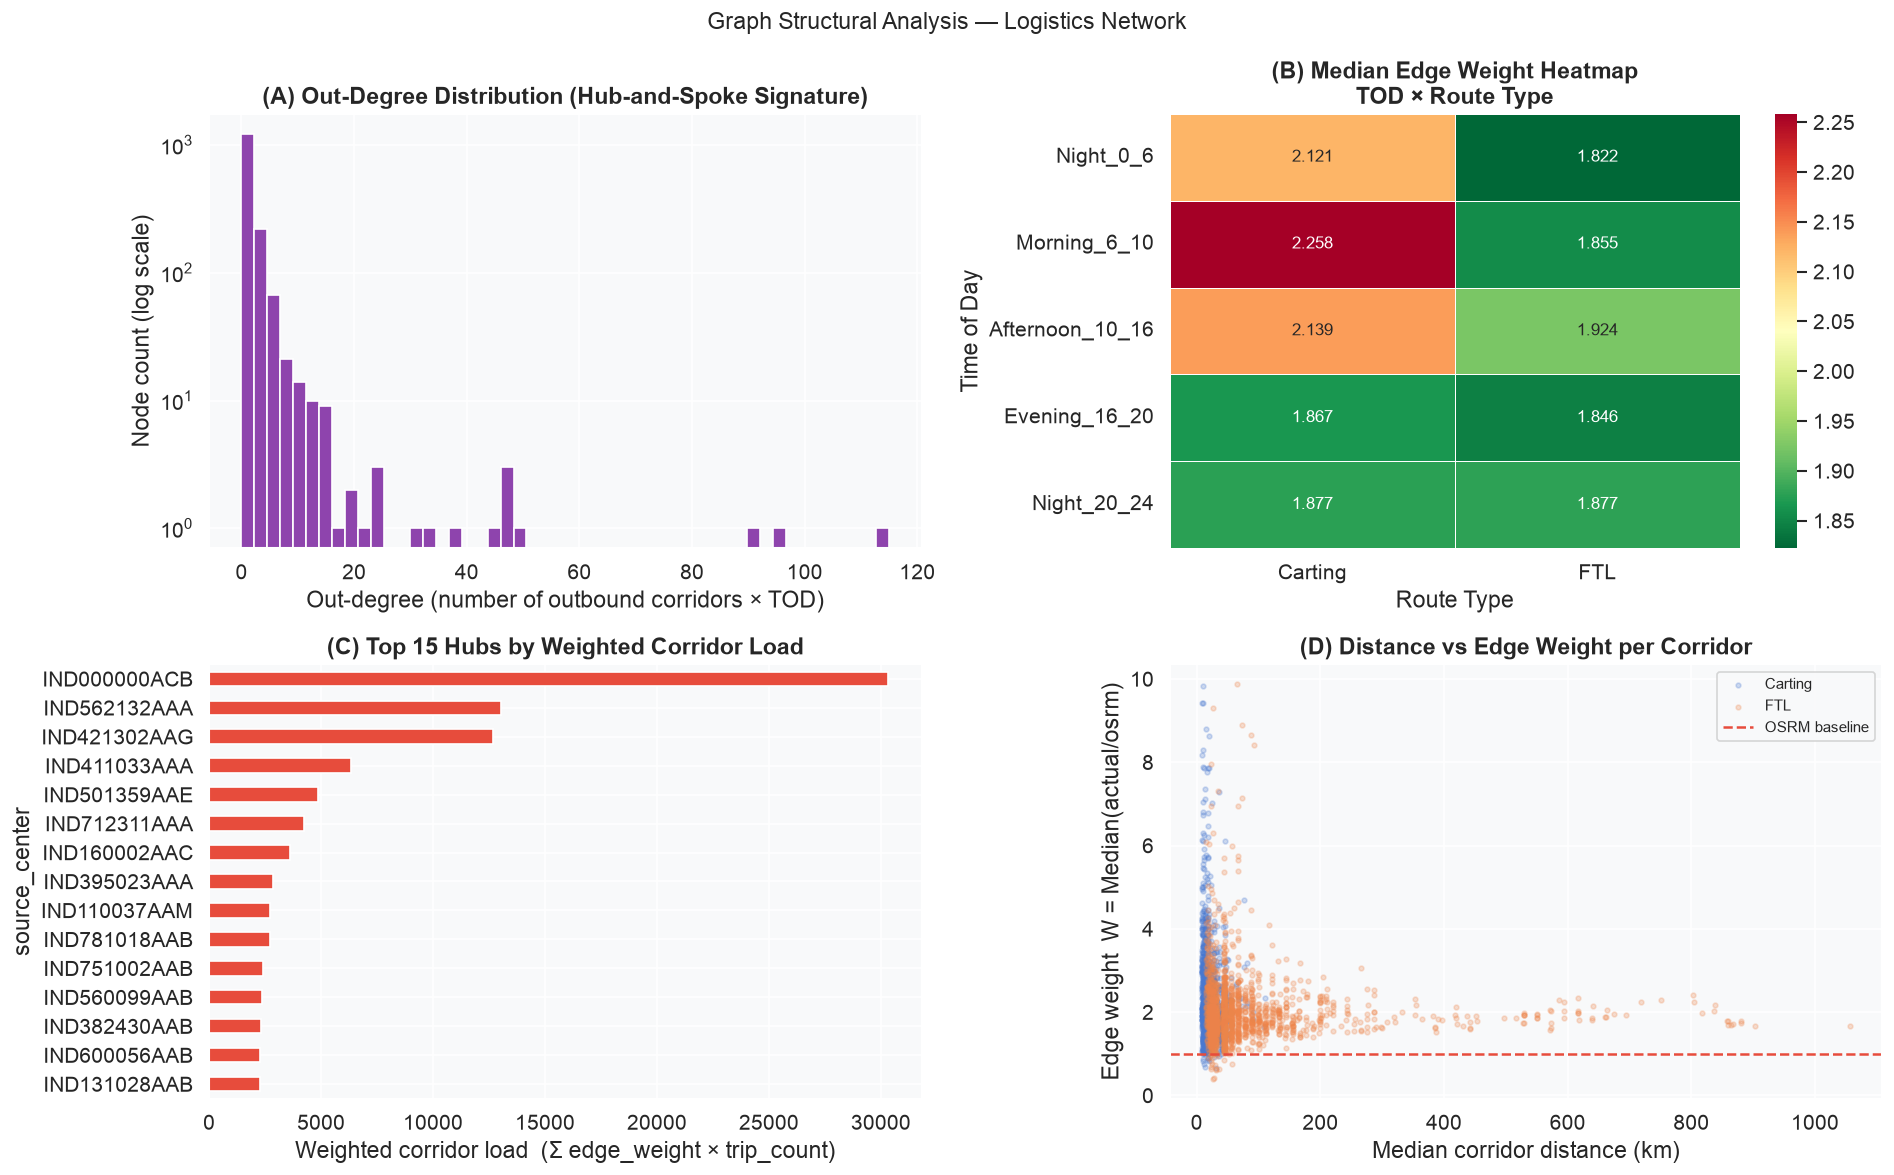


=== Top 10 Most Delayed Corridors (edge_weight, ≥20 trips) ===
source_center destination_center route_type     time_of_day  edge_weight  trip_count  median_dist_km
 IND847226AAA       IND842001AAA        FTL     Night_20_24     8.642858          41       88.407021
 IND847404AAB       IND842001AAA        FTL     Night_20_24     8.407895          21       92.530090
 IND829121AAA       IND834002AAB    Carting   Evening_16_20     7.290323          25       36.567425
 IND175015AAA       IND174001AAA        FTL       Night_0_6     6.954198          37       67.421837
 IND485001AAC       IND486771AAA        FTL       Night_0_6     5.651513          24       66.971474
 IND834002AAB       IND827013AAA    Carting   Evening_16_20     4.531760          90       49.987759
 IND152026AAA       IND000000ACA        FTL Afternoon_10_16     4.446281          91       88.555809
 IND834002AAB       IND827013AAA    Carting Afternoon_10_16     4.360000          49       54.629436
 IND742148AAA       IND7422

In [7]:
# ============================================================
# CELL 8 — GRAPH ANALYTICS & STRUCTURAL VALIDATION
# ============================================================

# ── Basic structural checks ──────────────────────────────────
simple_G = nx.DiGraph(G)   # collapse to simple graph for standard metrics

print("=== Structural Validation ===")
print(f"  Nodes with ≥1 outbound edge : {sum(1 for n in G if G.out_degree(n) > 0):,}")
print(f"  Nodes with ≥1 inbound  edge : {sum(1 for n in G if G.in_degree(n) > 0):,}")
print(f"  Isolated nodes (no edges)   : {len(list(nx.isolates(G))):,}")
print(f"  Self-loops                  : {nx.number_of_selfloops(G):,}")
is_weakly  = nx.is_weakly_connected(simple_G)
print(f"  Weakly connected            : {is_weakly}")
n_components = nx.number_weakly_connected_components(simple_G)
print(f"  Weakly connected components : {n_components}")
if not is_weakly:
    sizes = sorted(
        [len(c) for c in nx.weakly_connected_components(simple_G)],
        reverse=True
    )
    print(f"  Component sizes (top 5)     : {sizes[:5]}")

# ── Degree distribution ──────────────────────────────────────
out_degrees = dict(G.out_degree())
in_degrees  = dict(G.in_degree())

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Graph Structural Analysis — Logistics Network", fontsize=14)

# (A) Out-degree distribution
ax = axes[0, 0]
out_deg_vals = list(out_degrees.values())
ax.hist(out_deg_vals, bins=50, color=PURPLE, edgecolor="white", log=True)
ax.set_xlabel("Out-degree (number of outbound corridors × TOD)")
ax.set_ylabel("Node count (log scale)")
ax.set_title("(A) Out-Degree Distribution (Hub-and-Spoke Signature)")

# (B) Edge weight heatmap: TOD × route_type
ax = axes[0, 1]
pivot = (
    edge_weights_df
    .groupby(["time_of_day", "route_type"], observed=True)["edge_weight"]
    .median()
    .unstack("route_type")
    .reindex(TOD_LABELS)
)
sns.heatmap(pivot, ax=ax, annot=True, fmt=".3f", cmap="RdYlGn_r",
            linewidths=0.5, annot_kws={"size": 10})
ax.set_title("(B) Median Edge Weight Heatmap\nTOD × Route Type")
ax.set_ylabel("Time of Day")
ax.set_xlabel("Route Type")

# (C) Top 15 hubs by total weighted corridor load
ax = axes[1, 0]
hub_load = (
    edge_weights_df
    .groupby("source_center", observed=True)
    .apply(lambda g: (g["edge_weight"] * g["trip_count"]).sum())
    .sort_values(ascending=False)
    .head(15)
)
hub_load.plot(kind="barh", ax=ax, color=ACCENT, edgecolor="white")
ax.set_xlabel("Weighted corridor load  (Σ edge_weight × trip_count)")
ax.set_title("(C) Top 15 Hubs by Weighted Corridor Load")
ax.invert_yaxis()

# (D) Edge weight vs distance scatter
ax = axes[1, 1]
sample_e = edge_weights_df.sample(min(3000, len(edge_weights_df)), random_state=RANDOM_SEED)
for rt, grp in sample_e.groupby("route_type"):
    ax.scatter(grp["median_dist_km"], grp["edge_weight"],
               alpha=0.25, s=8, label=rt)
ax.axhline(1.0, color=ACCENT, linestyle="--", linewidth=1.5, label="OSRM baseline")
ax.set_xlabel("Median corridor distance (km)")
ax.set_ylabel("Edge weight  W = Median(actual/osrm)")
ax.set_title("(D) Distance vs Edge Weight per Corridor")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "graph_analytics.png"), bbox_inches="tight")
plt.show()

# ── Top corridors by delay severity ─────────────────────────
print("\n=== Top 10 Most Delayed Corridors (edge_weight, ≥20 trips) ===")
top_delayed = (
    edge_weights_df[edge_weights_df["trip_count"] >= 20]
    .sort_values("edge_weight", ascending=False)
    .head(10)
    [["source_center","destination_center","route_type",
      "time_of_day","edge_weight","trip_count","median_dist_km"]]
)
print(top_delayed.to_string(index=False))

# ── Neighbourhood inspection for a major hub ────────────────
hub = max(out_degrees, key=out_degrees.get)
print(f"\n=== Highest Out-Degree Hub: {hub} (degree={out_degrees[hub]}) ===")
neighbors = list(G.successors(hub))[:5]
print(f"  Sample successors: {neighbors}")


---
## 9 · Serialise Pipeline Artefacts

All three output artefacts are written to `../data/` for consumption by
the GraphSAGE training notebook (`03_graphsage_training.ipynb`).

| File | Format | Contents |
|---|---|---|
| `graph.gpickle` | Python pickle | Full `nx.MultiDiGraph` with all node & edge attributes |
| `node_features.parquet` | Parquet | Hub feature matrix (one row per hub) |
| `edge_weights.parquet` | Parquet | Stratified edge table (one row per corridor-TOD) |
| `pipeline_summary.json` | JSON | Reproducibility metadata |


In [8]:
# ============================================================
# CELL 9 — SERIALISE PIPELINE ARTEFACTS
# ============================================================

from datetime import datetime

# ── 1. Graph pickle ──────────────────────────────────────────
GRAPH_PATH = OUTPUT_DIR / "graph.gpickle"
with open(GRAPH_PATH, "wb") as f:
    pickle.dump(G, f, protocol=pickle.HIGHEST_PROTOCOL)
size_mb = os.path.getsize(GRAPH_PATH) / 1e6
print(f"✅  Graph saved   → {GRAPH_PATH}  ({size_mb:.1f} MB)")
print(f"    {G.number_of_nodes():,} nodes | {G.number_of_edges():,} edges")

# ── 2. Node feature parquet ──────────────────────────────────
NODE_PATH = OUTPUT_DIR / "node_features.parquet"
node_features_df.reset_index().to_parquet(NODE_PATH, index=False)
print(f"\n✅  Node features → {NODE_PATH}  ({os.path.getsize(NODE_PATH)/1e3:.0f} KB)")
print(f"    {len(node_features_df):,} hubs × {len(node_features_df.columns)} features")

# ── 3. Edge weights parquet ──────────────────────────────────
EDGE_PATH = OUTPUT_DIR / "edge_weights.parquet"
edge_weights_df.to_parquet(EDGE_PATH, index=False)
print(f"\n✅  Edge weights  → {EDGE_PATH}  ({os.path.getsize(EDGE_PATH)/1e3:.0f} KB)")
print(f"    {len(edge_weights_df):,} stratified edges × {len(edge_weights_df.columns)} attributes")

# ── 4. Pipeline summary JSON ─────────────────────────────────
summary = {
    "pipeline_version"        : "02_data_pipeline.ipynb",
    "generated_at"            : datetime.utcnow().isoformat(),
    "graph_type"              : type(G).__name__,
    "n_nodes"                 : G.number_of_nodes(),
    "n_edges"                 : G.number_of_edges(),
    "n_node_features"         : len(node_features_df.columns),
    "n_edge_attributes"       : len(edge_weights_df.columns),
    "stratification_keys"     : GROUPBY_KEYS,
    "time_of_day_labels"      : TOD_LABELS,
    "edge_weight_formula"     : "Median(actual_time / osrm_time)",
    "edge_weight_stats": {
        "min"   : float(edge_weights_df["edge_weight"].min()),
        "median": float(edge_weights_df["edge_weight"].median()),
        "mean"  : float(edge_weights_df["edge_weight"].mean()),
        "max"   : float(edge_weights_df["edge_weight"].max()),
    },
    "low_support_edges_pct"   : float(edge_weights_df["low_support"].mean() * 100),
    "artefacts": {
        "graph"         : str(GRAPH_PATH),
        "node_features" : str(NODE_PATH),
        "edge_weights"  : str(EDGE_PATH),
    }
}

SUMMARY_PATH = OUTPUT_DIR / "pipeline_summary.json"
with open(SUMMARY_PATH, "w") as f:
    json.dump(summary, f, indent=2)

print(f"\n✅  Summary JSON  → {SUMMARY_PATH}")
print("\n" + json.dumps(summary, indent=2))

# ── Verification: reload and spot-check ──────────────────────
print("\n=== Reload Verification ===")
with open(GRAPH_PATH, "rb") as f:
    G_reload = pickle.load(f)
assert G_reload.number_of_nodes() == G.number_of_nodes(), "Node count mismatch!"
assert G_reload.number_of_edges() == G.number_of_edges(), "Edge count mismatch!"
print(f"✅  Reload OK — {G_reload.number_of_nodes()} nodes, {G_reload.number_of_edges()} edges")

print("\n" + "="*60)
print("  PIPELINE COMPLETE — ARTEFACTS READY FOR GraphSAGE TRAINING")
print("="*60)
print("  Next step: 03_graphsage_training.ipynb")
print("     Load graph.gpickle → Convert to PyG HeteroData")
print("     → GraphSAGE neighbourhood sampling → Train ETA regressor")
print("="*60)


✅  Graph saved   → ../data/graph.gpickle  (1.0 MB)
    1,588 nodes | 3,983 edges

✅  Node features → ../data/node_features.parquet  (73 KB)
    1,588 hubs × 13 features

✅  Edge weights  → ../data/edge_weights.parquet  (169 KB)
    3,983 stratified edges × 14 attributes

✅  Summary JSON  → ../data/pipeline_summary.json

{
  "pipeline_version": "02_data_pipeline.ipynb",
  "generated_at": "2026-06-16T22:37:09.916249",
  "graph_type": "MultiDiGraph",
  "n_nodes": 1588,
  "n_edges": 3983,
  "n_node_features": 13,
  "n_edge_attributes": 14,
  "stratification_keys": [
    "source_center",
    "destination_center",
    "route_type",
    "time_of_day"
  ],
  "time_of_day_labels": [
    "Night_0_6",
    "Morning_6_10",
    "Afternoon_10_16",
    "Evening_16_20",
    "Night_20_24"
  ],
  "edge_weight_formula": "Median(actual_time / osrm_time)",
  "edge_weight_stats": {
    "min": 0.39992988109588623,
    "median": 1.9166667461395264,
    "mean": 2.1481375694274902,
    "max": 9.876922607421875
 